# Temperature Correlations and Kriging

## Load in calibrator data

In [1]:
from importlib import reload
try:
    reload(kriging_modified)
    from kriging import Kriging
except:
    import kriging
    reload(kriging)
    from kriging import Kriging
import numpy as np
import matplotlib.pyplot as plt

import time

In [2]:
freqarr, freqstep = np.linspace(0,250,4096,retstep=True) # Based on number of frequency channels of the antenna
minfreq = 100
# maxfreq = 
minfreqarg = int(minfreq/freqstep)
maxfreqarg = minfreqarg
# print(freqstep)
# print(freqarr[minfreqarg:maxfreqarg])
# freq = 100 # MHz
# freq_index = int(freq/freqstep)
freq=minfreq
freq_index = minfreqarg
print(freq_index)

1638


In [3]:
# Load in the data
year = '2021'
instrument = '100MHz'
channel = 'NS'

datadir = '../test_data/'+year+'/'+instrument+'/'+channel+'/'

save_mask = np.load(datadir+'shortdata_'+year+'_'+instrument+'_'+channel+'_mask.npy')
t_ant = np.load(datadir+'antsystime_'+year+'_'+instrument+'_'+channel+'.npy')
# Masked data
dat=np.load(datadir+'shortdata_meas_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]
lst=np.load(datadir+'shortlst_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]
t=np.load(datadir+'shortsystime_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]

# Unmasked data
# dat=np.load(datadir+'shortdata_meas_'+year+'_'+instrument+'_'+channel+'.npy')
# lst=np.load(datadir+'shortlst_'+year+'_'+instrument+'_'+channel+'.npy')
# t=np.load(datadir+'shortsystime_'+year+'_'+instrument+'_'+channel+'.npy')

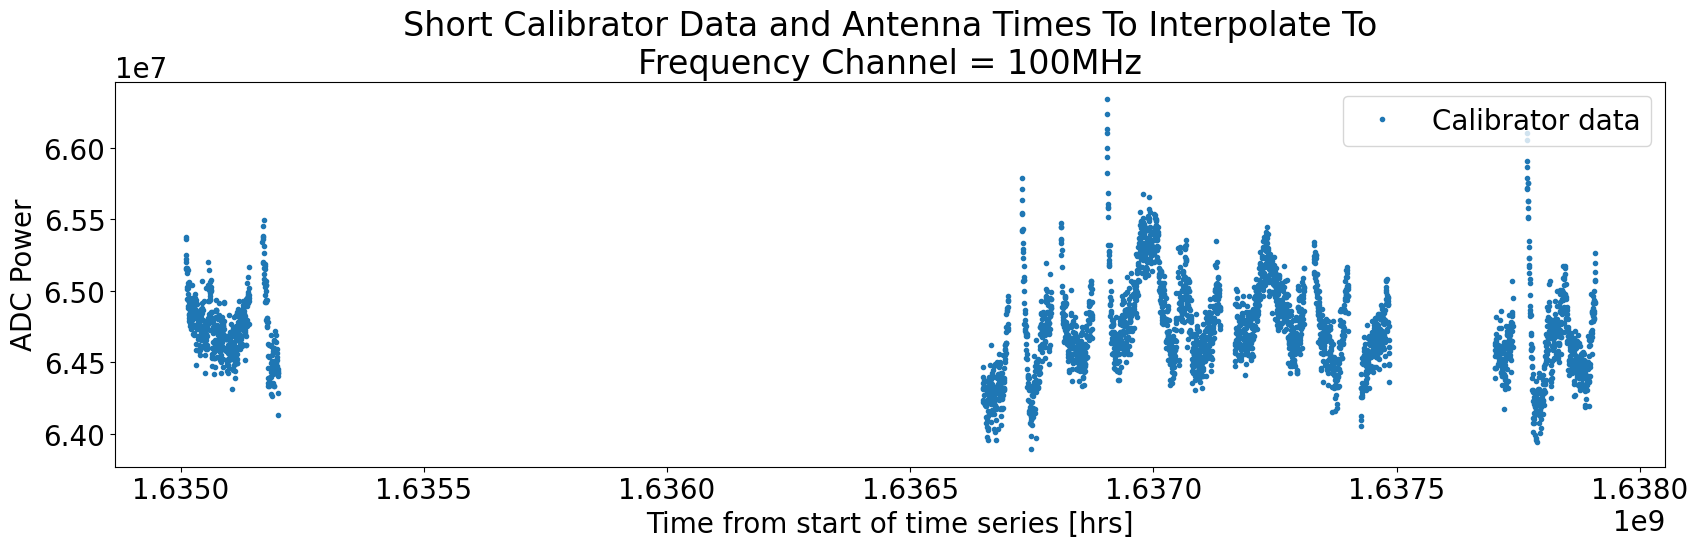

In [4]:
# Optional: select a subset of the data (mostly for testing)
# tmax=1.6374e9
# tmin=1.6365e9
# tmax=1.6377e9
tmax=np.inf
tmin=0

mask=(t>tmin)&(t<tmax)
tt=t[mask]
dd=dat[mask,:]

ant_mask = (t_ant>tmin)&(t_ant<tmax)
tt_ant = t_ant[ant_mask]

# Pick a freq_index to plot (the fit is done for all frequencies)
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(20,5))
# plt.plot((tt-tt[0])/3600,dd[:,freq_index],'.',label='Calibrator data')
plt.plot(tt,dd[:,freq_index],'.',label='Calibrator data')
# plt.plot((tt_ant-tt[0])/3600,[6.5e7 for ti in tt_ant],'.',color='red',label='Antenna times')
plt.title('Short Calibrator Data and Antenna Times To Interpolate To\nFrequency Channel = '+str(freq)+'MHz')
# plt.xlim(left=-40,right=60)
# plt.xlim(left=450)
plt.xlabel('Time from start of time series [hrs]')
plt.ylabel('ADC Power')
plt.legend(loc='upper right')
# plt.savefig('PreInterp3.png',bbox_inches='tight',dpi=300)
plt.show()

## Short Power - Temperature Correlations

In [5]:
import sys
from importlib import reload
reload(sys)
import sys

In [3]:
# sys.path.remove("/home/s/sievers/lauriea/prizm-data-wrangling/prizmdatawrangling")

In [6]:
sys.path

['/scinet/niagara/software/2019b/opt/base/python/3.11.5/lib/python311.zip',
 '/scinet/niagara/software/2019b/opt/base/python/3.11.5/lib/python3.11',
 '/scinet/niagara/software/2019b/opt/base/python/3.11.5/lib/python3.11/lib-dynload',
 '',
 '/home/s/sievers/lauriea/.virtualenvs/prizmenv2/lib/python3.11/site-packages',
 '/home/s/sievers/lauriea/.virtualenvs/prizmenv2/lib/python3.11/site-packages/prizmdatawrangling-1.0-py3.11.egg',
 '/home/s/sievers/lauriea/.virtualenvs/prizmenv2/lib/python3.11/site-packages/setuptools/_vendor',
 '/scinet/niagara/software/2019b/opt/base/python/3.11.5/lib/python3.11/site-packages']

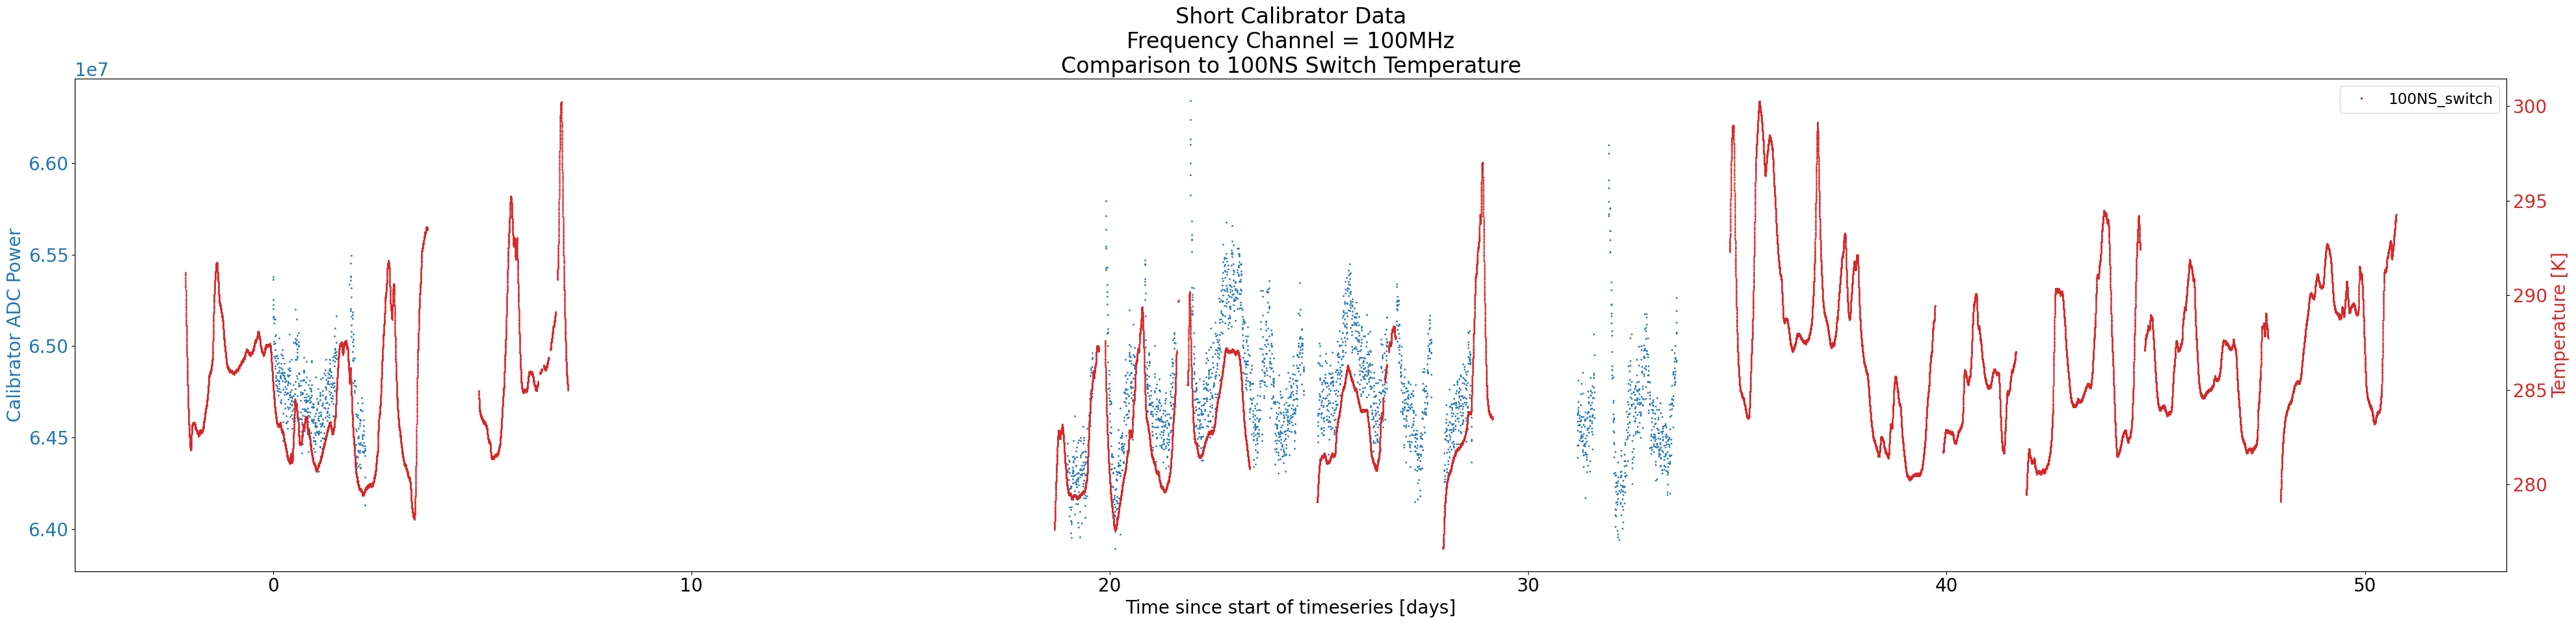

In [5]:
# Importing system temperature to check correlations between temperature variations and calibrator power variations
from data import get_temperatures, interpolate_temperature

# path to temperature directories (2021 only)
plt.rcParams.update({'font.size': 20})
path2dir = f'/project/s/sievers/prizm/marion2022/prizm-{instrument[:-3]}/data_{instrument}/temperatures'
# temp_type = 'ambient'
# T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
# T_amb, systime_amb, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, tt)
temp_type = '100NS_switch'
T_switch = get_temperatures(instrument, path2dir, temp_type=temp_type)
# T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, tt)
systime_switch = (T_switch['time_sys_start'] + T_switch['time_sys_stop']) / 2

# -------------------------------------------
fig, ax1 = plt.subplots(figsize=(40,10))

color = 'tab:blue'
ax1.set_xlabel('Time since start of timeseries [days]')
ax1.set_ylabel('Calibrator ADC Power',color=color)
# ax1.plot(t, data1, color=color)
ax1.plot((tt-tt[0])/3600/24,dd[:,freq_index],color=color,label='Calibrator data',ms=2,marker='.',ls='None')

ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Temperature [K]', color=color)  # we already handled the x-label with ax1
# ax2.plot((systime_amb-tt[0])/3600/24, T_amb, color=color,ls='none',marker='.',label='ambient')
ax2.plot((systime_switch-tt[0])/3600/24, T_switch[f'temp_{temp_type}'], color=color,ms=1,ls='none',marker='.',label='100NS_switch')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(markerscale=3,fontsize='small')

plt.title('Short Calibrator Data\nFrequency Channel = '+str(freq)+'MHz\nComparison to 100NS Switch Temperature')
fig.tight_layout()  # otherwise the right y-label is slightly clipped

plt.show()

In [6]:
# Plot all temperatures, no interpolation
temp_type = ['ambient','100NS_bot_lna','100NS_top_lna','100NS_switch','100NS_noise']

plt.rcParams.update({'font.size': 15})
fig, axs = plt.subplots(nrows=2,ncols=1,sharex=True,figsize=(20,10),dpi=600)
for i in range(len(temp_type)):
    
    T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type[i])
    temp_time = (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2
    
    #plt.plot((temp_time - temp_time[0]) /3600/24, T_phys[f'temp_{temp_type[i]}'],'.',ms=1,label=temp_type[i])
    axs[0].plot((temp_time-tt[0])/3600/24, T_phys[f'temp_{temp_type[i]}'],'.',ms=1,label=temp_type[i])
    #if i == 0: break # testing
        
axs[1].plot((tt-tt[0])/3600/24,dd[:,freq_index],'.',ms=2,label='Calibrator data',color='k')

axs[0].legend(fontsize='small',markerscale=6,ncols=2,loc='upper right')
axs[0].grid('on')
axs[1].grid('on')
axs[0].set_ylim(top=310,bottom=270)
axs[1].set_xlabel('Time since start of time series [days]')
# axs[1].set_xlabel('UNIX Timestamp [s]')
axs[0].set_ylabel('Temperature [K]')
axs[1].set_ylabel('ADC Power')
axs[1].legend(fontsize='small',markerscale=3,loc='upper right')
# axs[0].set_xlim(left=1.6365e9,right=1.638e9)
# axs[0].set_xlim(left=17,right=34)
plt.show()

### Comparing raw to interpolated temperature

Basically is it ok to use interpolated temperature to compute the ACF (at least for now for exploration purposes)?

In [ ]:
# WIP

### Making Autocorrelation Function of Short Power vs. Temperature Separation

So apparently this is the __wrong way to do it__, and Mohan, Jon and Cynthia say what I should be computing is the cross-correlation of the short power timestream and the temperature timestream. Makes sense to me.

In [15]:
from test_short_interp import make_acf # import ACF computing function (normally same one that is in kriging.py)

In [16]:
# Get 'switch' temperature data and interpolate it to the short data times
temp_type = '100NS_switch'
T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, tt)

dt = 0.5
tmax = 25
tot, wt = make_acf(dat=dd[interp_inds,freq_index]-dd[interp_inds,freq_index].mean(),t=T_switch,dt=dt,tmax=tmax) # dd set to 100MHz freq channel right now, dt = 1 K, tmax = 25 K

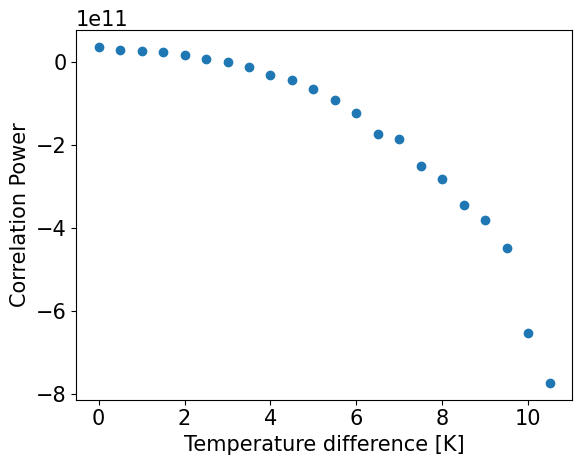

In [11]:
mm = wt > 0 # weight criterion
temp_vec = np.arange(len(tot))[mm]*dt
plt.plot(temp_vec,tot[mm]/wt[mm],'o')
plt.xlabel('Temperature difference [K]')
plt.ylabel('Correlation Power')
plt.show()

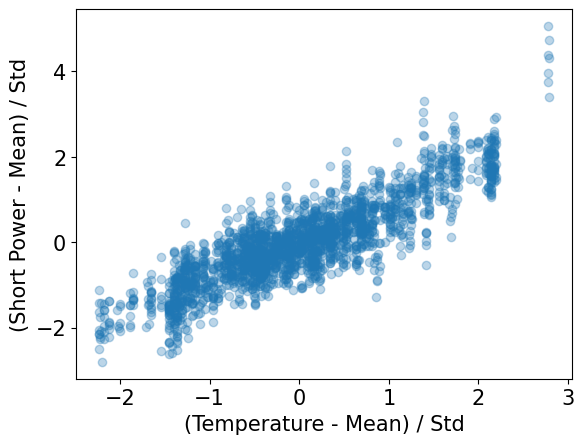

In [12]:
# Simple plot of short power vs. temperature
plt.plot((T_switch-T_switch.mean())/np.std(T_switch),(dd[interp_inds,freq_index]-dd[interp_inds,freq_index].mean())/np.std(dd[interp_inds,freq_index]),'o',alpha=0.3)
plt.xlabel('(Temperature - Mean) / Std',fontsize=15)
plt.ylabel('(Short Power - Mean) / Std',fontsize=15)
plt.show()

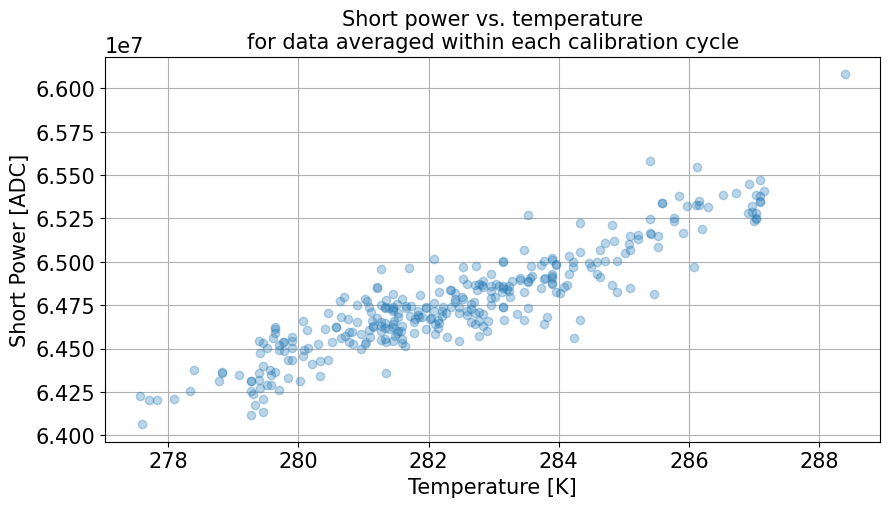

In [53]:
# Same plot but with averaging within each calibration cycle

from kriging import Kriging
# Initialize Kriging class
krig_object = Kriging(systime=tt,data=dd,interp_times=t_ant,tmax_mask=np.nan,tmin_mask=np.nan,
                 minfreq=None,maxfreq=None,minfreqarg=freq_index,maxfreqarg=freq_index)

# Use smooth_acf to average the values
avgd_times, avgd_data, avgd_std = krig_object.smooth_acf(tvec=tt,acf=dd[:,freq_index],cycle_jump=5*60,isACF=False)
# syntax: smooth_acf(self,tvec,acf,cycle_jump=60,isACF=False)

# Plot averaged values
# plt.figure(figsize=(20,5))
# plt.scatter(avgd_times,avgd_data,marker='.')
# plt.show()

# Interpolate temperatures to the averaged times
T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, avgd_times)

# Make short power vs. temperature scatterplot
plt.figure(figsize=(10,5))
plt.plot(T_switch,avgd_data[interp_inds],'o',alpha=0.3)
plt.xlabel('Temperature [K]',fontsize=15)
plt.ylabel('Short Power [ADC]',fontsize=15)
plt.title('Short power vs. temperature\nfor data averaged within each calibration cycle',fontsize=15)
plt.grid()
plt.show()

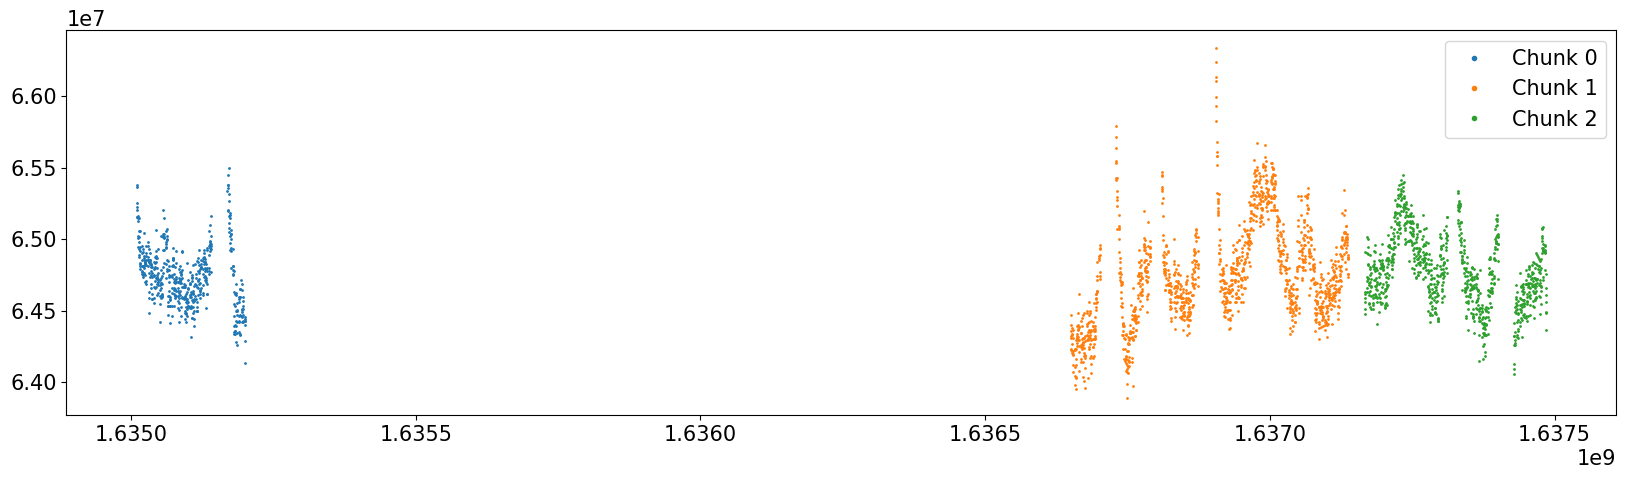

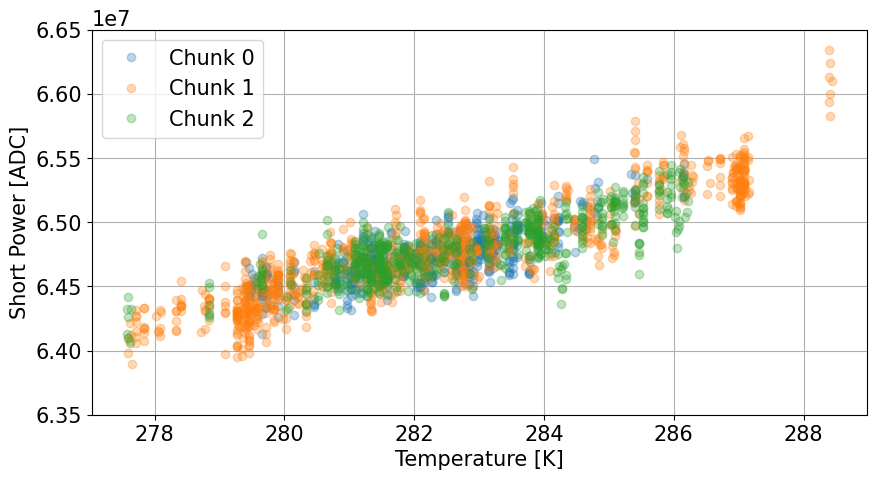

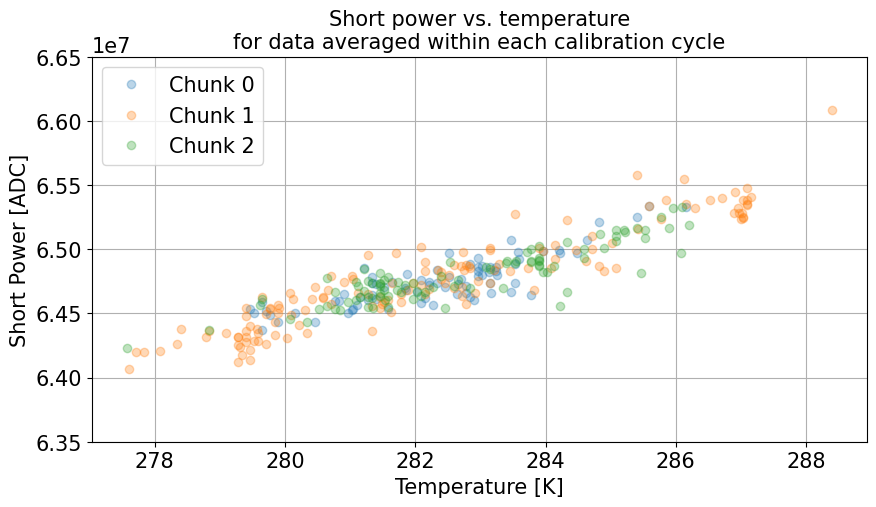

In [57]:
# Same plot of short power vs. temperature for 3 different chunks
temp_type = '100NS_switch'
T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
time_stops = np.array([0,1.6365e9,1.63715e9,1.6376e9])

# Plot the 3 different chunks
plt.figure(figsize=(20,5))
for i in range(3):
    time_rng = tt[(tt>time_stops[i]) & (tt<time_stops[i+1])]
    dat_rng = dd[(tt>time_stops[i]) & (tt<time_stops[i+1]),freq_index]
    plt.plot(time_rng,dat_rng,label='Chunk '+str(i),marker='.',ms=2,ls='none')

plt.legend(markerscale=3)
plt.show()




# Plot short power vs. temperature scatterplot
plt.figure(figsize=(10,5))
for i in range(3):
    try:
        time_rng = tt[(tt>time_stops[i]) & (tt<time_stops[i+1])]
        dat_rng = dd[(tt>time_stops[i]) & (tt<time_stops[i+1]),:]
        T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, time_rng)
    except:
        break
    
    plt.plot(T_switch,dat_rng[interp_inds,freq_index],'o',alpha=0.3,label='Chunk '+str(i))


plt.ylim(top=6.65e7,bottom=6.35e7)
plt.xlabel('Temperature [K]')
plt.ylabel('Short Power [ADC]')
plt.grid()
plt.legend()
plt.show()





# Short power vs. temperature for data averaged within each calibration cycle, for 3 different chunks
plt.figure(figsize=(10,5))
for i in range(3):
    time_rng = tt[(tt>time_stops[i]) & (tt<time_stops[i+1])]
    dat_rng = dd[(tt>time_stops[i]) & (tt<time_stops[i+1]),:]
    
    krig_object = Kriging(systime=time_rng,data=dat_rng,interp_times=t_ant,tmax_mask=np.nan,tmin_mask=np.nan,
                 minfreq=None,maxfreq=None,minfreqarg=freq_index,maxfreqarg=freq_index)

    # Use smooth_acf to average the values
    avgd_times, avgd_data, avgd_std = krig_object.smooth_acf(tvec=time_rng,acf=dat_rng[:,freq_index],cycle_jump=5*60,isACF=False)
    # syntax: smooth_acf(self,tvec,acf,cycle_jump=60,isACF=False)

    # Interpolate temperatures to the averaged times
    T_switch, systime_switch, interp_inds = interpolate_temperature(T_phys[f'temp_{temp_type}'], (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2, avgd_times)

    # Make short power vs. temperature scatterplot
    plt.plot(T_switch,avgd_data[interp_inds],'o',alpha=0.3,label='Chunk '+str(i))

plt.ylim(top=6.65e7,bottom=6.35e7)
plt.xlabel('Temperature [K]',fontsize=15)
plt.ylabel('Short Power [ADC]',fontsize=15)
plt.title('Short power vs. temperature\nfor data averaged within each calibration cycle',fontsize=15)
plt.legend()
plt.grid()
plt.show()

Chunk 0 measurement noise est.: 210117.74927351033
Chunk 1 measurement noise est.: 352034.6516509522
Chunk 2 measurement noise est.: 242958.91593428564


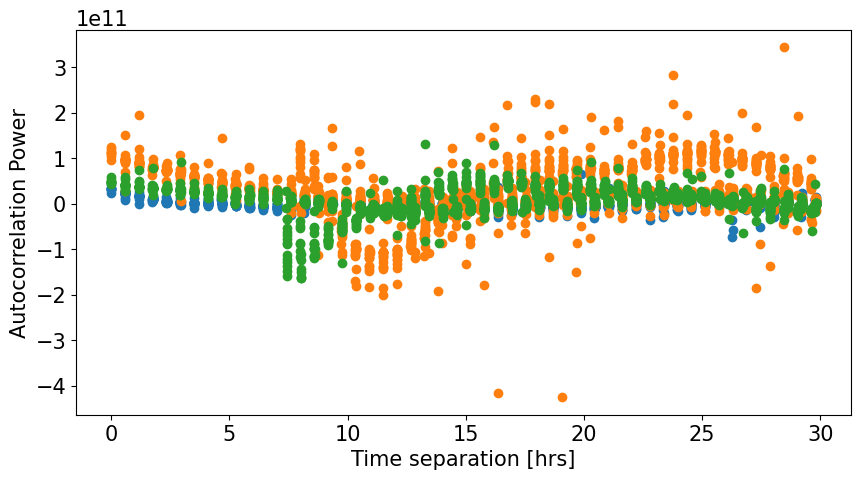

Full f=100MHz dataset measurement noise est.: 302390.1502397172


In [68]:
# Compute the ACF for each chunk to get an estimate of the measurement noise from dt=0
plt.figure(figsize=(10,5))

for i in range(3):
    time_rng = tt[(tt>time_stops[i]) & (tt<time_stops[i+1])]
    dat_rng = dd[(tt>time_stops[i]) & (tt<time_stops[i+1]),:][:,freq_index]
    dt = 5
    tot, wt = make_acf(dat=(dat_rng-dat_rng.mean()),t=time_rng,dt=dt,tmax=30*3600)
    
    # plot ACF here
    mm = wt > 0
    
    plt.plot(np.arange(len(tot))[mm]*dt/3600,(tot[mm]/wt[mm]),'o')
    print('Chunk',i,'measurement noise est.:',np.sqrt((tot[mm]/wt[mm])[0]))

plt.xlabel('Time separation [hrs]')
plt.ylabel('Autocorrelation Power')
plt.show()

# Full ACF
tot, wt = make_acf(dat=(dd[:,freq_index]-dd[:,freq_index].mean()),t=tt,dt=dt,tmax=5*3600)
mm = wt>0
print('Full f=100MHz dataset measurement noise est.:',np.sqrt((tot[mm]/wt[mm])[0]))

### Computing CROSS-Correlation of Short Power and Temperature

In [7]:
import test_short_interp
reload(test_short_interp)
# from test_short_interp import make_ccf
from test_short_interp import make_ccf_2sided
from test_short_interp import make_acf

#### Test the Cross-Correlation Function with Mock Datasets

2 offset sinc functions

In [8]:
def sincfunc(x,x0):
    return np.sin(x-x0)/(x-x0)

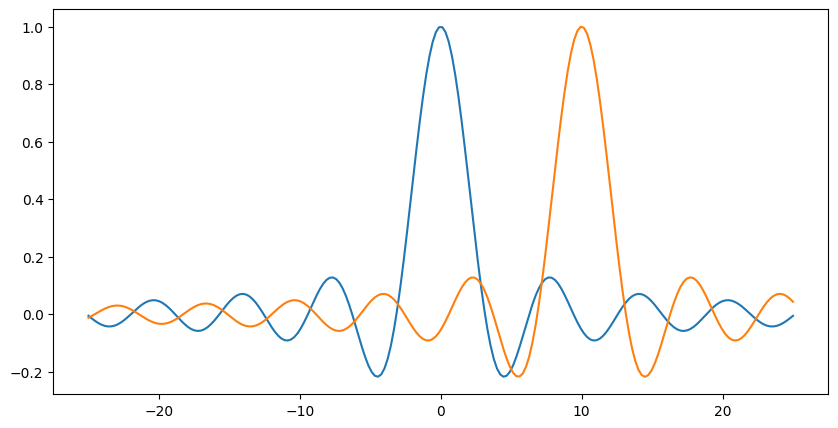

In [57]:
fig, ax = plt.subplots(figsize=(10,5))
x_range1,step = np.linspace(-25,25,220,retstep=True)
x_range2 = np.linspace(-25,25,220)
x_range2 = np.linspace(-25,25,220)
# x_range2 = np.linspace(-15,35,220)

testdat1 = sincfunc(x_range1,0)
testdat2 = sincfunc(x_range2,10)
# testdat2 = sincfunc(x_range2,0)
# print(60*step)

ax.plot(x_range1,testdat1)
ax.plot(x_range2,testdat2)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

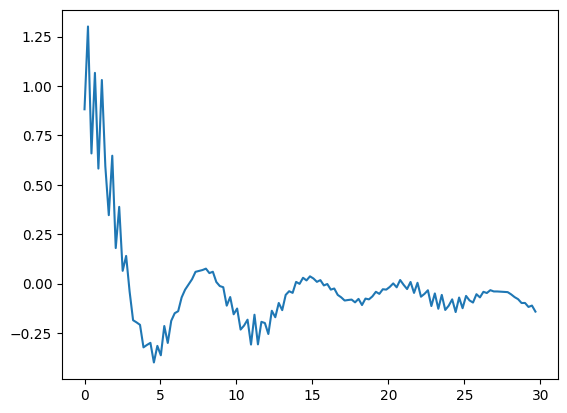

In [23]:
# Checking that ACF function has amplitude of 1 at dt=0 when you give it normalized data
tot, wt = make_acf(dat=(testdat2-testdat2.mean())/testdat2.std(),t=x_range2,dt=step,tmax=30)
mm = wt>0
plt.plot(np.arange(len(tot))[mm]*dt,tot[mm]/wt[mm])
plt.show()

On loop # 0
On loop # 100
On loop # 200


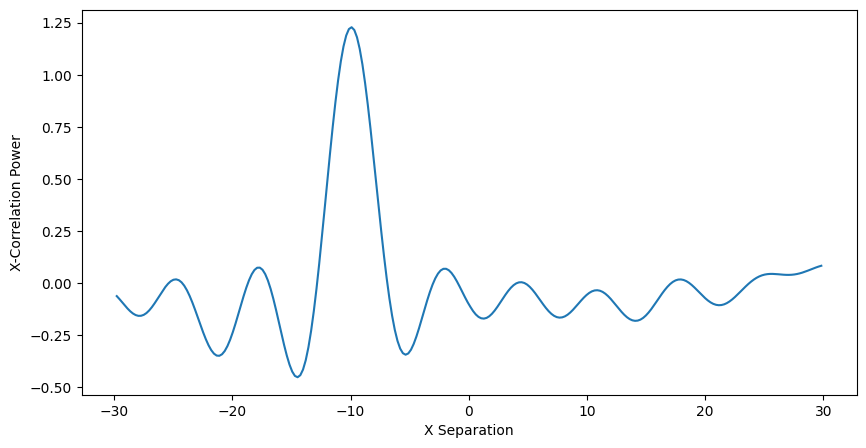

-9.908675799086808


In [24]:
dt=step
tot, wt, bins = make_ccf_2sided(dat1=(testdat1-testdat1.mean())/testdat1.std(),t1=x_range1,
                                dat2=(testdat2-testdat2.mean())/testdat2.std(),t2=x_range2,dt=dt,tmax=30)
mm = wt > 0
# dxrange = np.arange(len(tot))[mm]*dt
# print(bins)
plt.figure(figsize=(10,5))
plt.plot(bins[mm],tot[mm]/wt[mm])
plt.xlabel('X Separation',fontsize=10)
plt.ylabel('X-Correlation Power',fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

print(bins[mm][np.argmax(tot[mm]/wt[mm])])

#### Now X-Corr of Short Power and Temperature

In [32]:
# Temperature data
temp_type = '100NS_switch'
T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
temp_time = (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2
temp_mask = (temp_time>tmin)&(temp_time<tmax)


# Compute Short Power - Temperature Cross-Correlation
# Remember this is a x-corr with respect to time separation!!!!!!
dt=30
# tot, wt = make_ccf(dat1=(dd[:,freq_index]-dd[:,freq_index].mean()),t1=tt,dat2=(T_phys[f'temp_{temp_type}'][temp_mask]-T_phys[f'temp_{temp_type}'][temp_mask].mean()),t2=temp_time[temp_mask],dt=dt,tmax=30*3600)
# tot, wt = make_ccf(dat1=(dd[:,freq_index]-dd[:,freq_index].mean())/np.std(dd[:,freq_index]),t1=tt,dat2=(T_phys[f'temp_{temp_type}'][temp_mask]-T_phys[f'temp_{temp_type}'][temp_mask].mean())/np.std(T_phys[f'temp_{temp_type}'][temp_mask]),t2=temp_time[temp_mask],dt=dt,tmax=30*3600)
tot, wt, bins = make_ccf_2sided(dat1=(dd[:,freq_index]-np.nanmean(dd[:,freq_index]))/np.nanstd(dd[:,freq_index]),t1=tt,
                                dat2=(T_phys[f'temp_{temp_type}'][temp_mask]-np.nanmean(T_phys[f'temp_{temp_type}'][temp_mask]))/np.nanstd(T_phys[f'temp_{temp_type}'][temp_mask]),t2=temp_time[temp_mask],dt=dt,tmax=30*3600)
# syntax: make_ccf(dat1,t1,dat2,t2,dt,tmax)

On loop # 0
On loop # 100
On loop # 200
On loop # 300
On loop # 400
On loop # 500
On loop # 600
On loop # 700
On loop # 800
On loop # 900
On loop # 1000
On loop # 1100
On loop # 1200
On loop # 1300
On loop # 1400
On loop # 1500
On loop # 1600
On loop # 1700
On loop # 1800
On loop # 1900
On loop # 2000
On loop # 2100
On loop # 2200
On loop # 2300
On loop # 2400
On loop # 2500
On loop # 2600
On loop # 2700
On loop # 2800
On loop # 2900
On loop # 3000
On loop # 3100
On loop # 3200


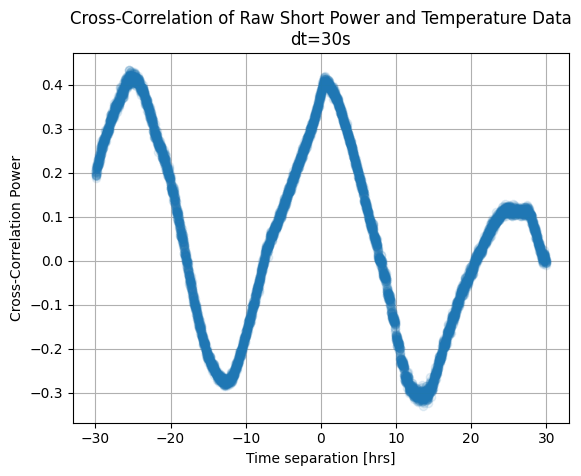

In [34]:
# Plot results
mm = (wt > 0)
dtrange = bins[mm]

plt.rcParams.update({'font.size': 10})
plt.plot(dtrange/3600,tot[mm]/wt[mm],'o',alpha=0.1)

plt.ylabel('Cross-Correlation Power')
# plt.ylabel('wt power (no wt division)')
plt.xlabel('Time separation [hrs]')
# plt.xlim(0,0.5)
# plt.xticks(fontsize=10)
# plt.yticks(fontsize=10)
# plt.legend()
plt.grid()
plt.title('Cross-Correlation of Raw Short Power and Temperature Data\ndt='+str(dt)+'s')
plt.show()

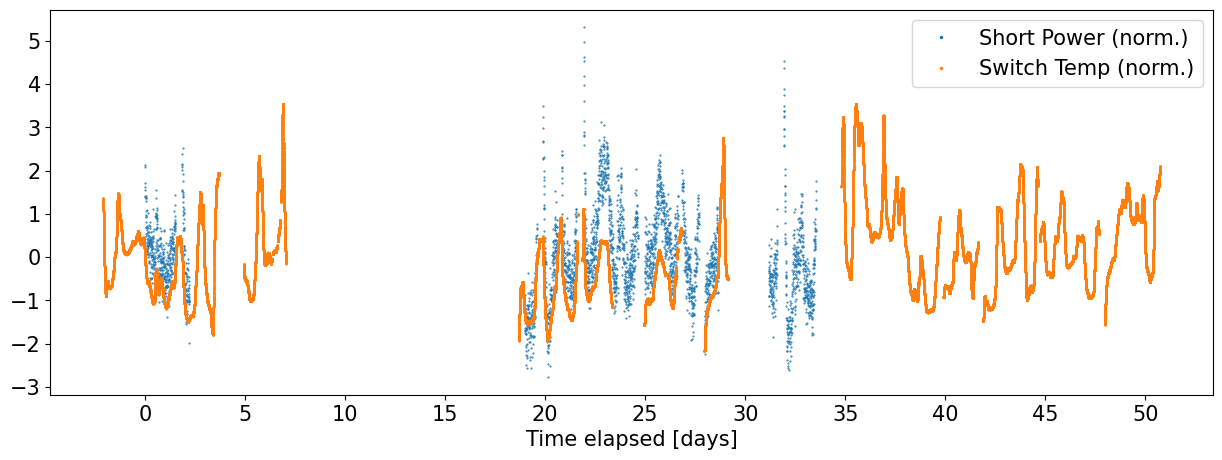

In [56]:
plt.figure(figsize=(15,5))
plt.plot((tt-tt[0])/3600/24,(dd[:,freq_index]-dd[:,freq_index].mean())/np.std(dd[:,freq_index]),ms=1,marker='.',ls='None',label='Short Power (norm.)')
plt.plot((temp_time[temp_mask]-tt[0])/3600/24,(T_phys[f'temp_{temp_type}'][temp_mask]-T_phys[f'temp_{temp_type}'][temp_mask].mean())/np.std(T_phys[f'temp_{temp_type}'][temp_mask]),ms=1,marker='.',ls='None',label='Switch Temp (norm.)')
plt.xlabel('Time elapsed [days]')
plt.xticks(np.linspace(0,50,11))
plt.legend(markerscale=3)
plt.show()

### Alternative X-Corr Algorithm

In [25]:
import test_short_interp
reload(test_short_interp)
from test_short_interp import make_ccf_2sided_binning

In [30]:
temp_type = '100NS_switch'
T_phys = get_temperatures(instrument, path2dir, temp_type=temp_type)
temp_time = (T_phys['time_sys_start'] + T_phys['time_sys_stop']) / 2
tmax=np.inf
tmin=0
temp_mask = (temp_time>tmin)&(temp_time<tmax)

dt=1800
dt_bins, ccf_tot = make_ccf_2sided_binning(dat1=(dd[:,freq_index]-np.nanmean(dd[:,freq_index])),t1=tt,
                                  dat2=(T_phys[f'temp_{temp_type}'][temp_mask]-np.nanmean(T_phys[f'temp_{temp_type}'][temp_mask])),t2=temp_time[temp_mask],
                                  dt=dt,tmax=30*3600)

# dt_bins, ccf_tot = make_ccf_2sided_binning(dat1=(T_phys[f'temp_{temp_type}'][temp_mask]-np.nanmean(T_phys[f'temp_{temp_type}'][temp_mask])),t1=temp_time[temp_mask],
#                                   dat2=(dd[:,freq_index]-np.nanmean(dd[:,freq_index])),t2=tt,
#                                   dt=dt,tmax=30*3600)


print(ccf_tot)

[ 0.25603584  0.32167692  0.38989342  0.45657636  0.52192243  0.58349506
  0.60669327  0.62574349  0.68263922  0.71975028  0.73335373  0.72986059
  0.70336504  0.66184752  0.60793239  0.53188106  0.4567672   0.40074356
  0.35689719  0.29317526  0.23788946  0.18881347  0.12910533  0.07171189
  0.00648552 -0.05589536 -0.12196735 -0.17085157 -0.22281726 -0.27865779
 -0.31614825 -0.34556441 -0.38168871 -0.39205797 -0.39127396 -0.40502658
 -0.40444445 -0.38806723 -0.35722733 -0.31037393 -0.25103452 -0.20379302
 -0.158403   -0.11211301 -0.06576785 -0.02751408  0.01691769  0.06071152
  0.08739674  0.11924409  0.15553812  0.19534772  0.24434138  0.29288906
  0.3501875   0.40712841  0.46456704  0.531769    0.59550008  0.66587515
  0.72393112  0.74278078  0.71851424  0.6775442   0.65706301  0.59843821
  0.55049916  0.49490616  0.43371551  0.37154227  0.30598952  0.24934383
  0.18728903  0.14886462  0.08076435  0.04784424 -0.01646338 -0.06216099
 -0.12154877 -0.19350492 -0.27393633 -0.35320507 -0

0.5


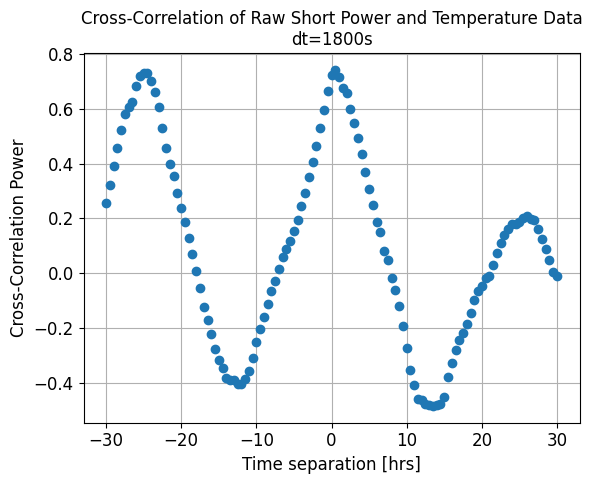

In [31]:
plt.rcParams.update({'font.size': 12})
plt.plot(dt_bins/3600,ccf_tot,'o')
print(dt_bins[np.argmax(ccf_tot)]/3600)

plt.rcParams.update({'font.size': 10})
plt.ylabel('Cross-Correlation Power')
plt.xlabel('Time separation [hrs]')
plt.grid()
plt.title('Cross-Correlation of Raw Short Power and Temperature Data\ndt='+str(dt)+'s')
plt.show()

#### Test: Running alternative CCF algorithm on twice the same dataset (<=>ACF)

[ 0.03236404  0.03919523  0.0936064   0.14165035  0.19963568  0.23973157
  0.26265654  0.29747272  0.26306226  0.28928829  0.30919319  0.3301296
  0.32740241  0.33956847  0.35470552  0.31769192  0.30187212  0.27762456
  0.30726292  0.28800773  0.28565092  0.2560201   0.20054178  0.18570632
  0.13581378  0.12345176  0.1098921   0.0817621   0.051996   -0.01375715
 -0.034408   -0.07984631 -0.07455517 -0.12602552 -0.09982343 -0.08948478
 -0.08669459 -0.04935882 -0.02361644  0.03488485  0.03837225  0.06245069
  0.07927077  0.1376656   0.13699481  0.12892441  0.15822288  0.18305611
  0.20941311  0.240013    0.3395563   0.38666817  0.39881597  0.44703821
  0.52131884  0.59080302  0.68077572  0.78885692  0.83826599  0.90333711
  1.00000393  0.90333711  0.83826599  0.78885692  0.68077572  0.59080302
  0.52131884  0.44703821  0.39881597  0.38666817  0.3395563   0.240013
  0.20941311  0.18305611  0.15822288  0.12892441  0.13699481  0.1376656
  0.07927077  0.06245069  0.03837225  0.03488485 -0.023

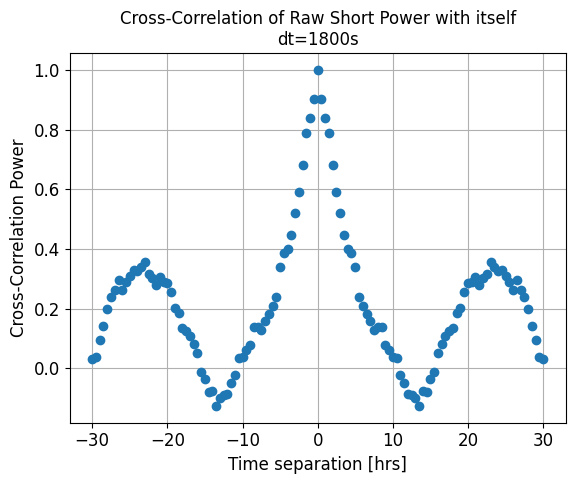

In [28]:
dt=1800
dt_bins, ccf_tot = make_ccf_2sided_binning(dat1=(dd[:,freq_index]-np.nanmean(dd[:,freq_index])),t1=tt,
                                  dat2=(dd[:,freq_index]-np.nanmean(dd[:,freq_index])),t2=tt,
                                  dt=dt,tmax=30*3600)
print(ccf_tot)

plt.rcParams.update({'font.size': 12})
plt.plot(dt_bins/3600,ccf_tot,'o')
print(np.max(ccf_tot))

plt.rcParams.update({'font.size': 10})
plt.ylabel('Cross-Correlation Power')
plt.xlabel('Time separation [hrs]')
plt.grid()
plt.title('Cross-Correlation of Raw Short Power with itself\ndt='+str(dt)+'s')
plt.show()

#### Test: Running alternative CCF algorithm on the shifted sinc function

[-0.12655056 -0.09845343 -0.06961332 -0.04128568 -0.01475101  0.00872591
  0.02794421  0.04182173  0.04945295  0.05016459  0.04356313  0.02956956
  0.00843925 -0.01923332 -0.05252344 -0.09019664 -0.13073984 -0.17240301
 -0.2132524  -0.25123617 -0.28426199 -0.31028436 -0.32739651 -0.33392078
 -0.32849016 -0.31011538 -0.27823386 -0.23273959 -0.17399496 -0.10282706
 -0.02051014  0.07126425  0.17042973  0.27460046  0.38114019  0.48724401
  0.59003077  0.68664198  0.7743422   0.85061519  0.91325122  0.96042185
  0.99074048  1.00330791  0.99774303  0.97419845  0.93336051  0.87643231
  0.80509848  0.72147075  0.62801503  0.52746216  0.42270683  0.31670001
  0.21234128  0.11237666  0.01930672 -0.06469189 -0.13782953 -0.19875045
 -0.24656306 -0.28085352 -0.30168247 -0.30956517 -0.30543546 -0.29059488
 -0.26664906 -0.23543417 -0.19893688 -0.15921161 -0.11829845 -0.07814508
 -0.04053535 -0.00702686  0.02110054  0.04288364  0.05770076  0.06528175
  0.0657026   0.05936504  0.0469624   0.02943365  0

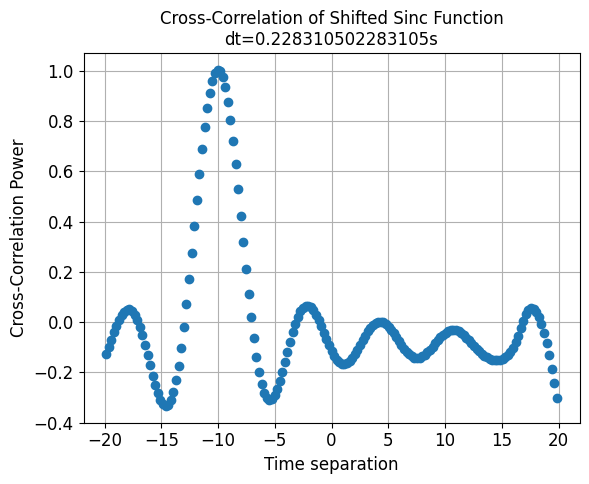

In [60]:
dt=step
dt_bins, ccf_tot = make_ccf_2sided_binning(dat1=testdat1-np.nanmean(testdat1),t1=x_range1,
                                  dat2=testdat2-np.nanmean(testdat2),t2=x_range2,
                                  dt=dt,tmax=20)
print(ccf_tot)

plt.rcParams.update({'font.size': 12})
plt.plot(dt_bins,ccf_tot,'o')
print(np.max(ccf_tot))

plt.rcParams.update({'font.size': 10})
plt.ylabel('Cross-Correlation Power')
plt.xlabel('Time separation')
plt.grid()
plt.title('Cross-Correlation of Shifted Sinc Function\ndt='+str(dt)+'s')
plt.show()

### Cross-correlation between other calibrators and temperature

100 Ohm, 50 Ohm

noise source? -- previously investigated by Fernando I think

### Computing Temperature Autocorrelation

Just to see if the temperature varies with some sort of pattern over time, logically it should get cold at night and hot during the day so there should be some sort of correlation.

In [ ]:
# WIP